**Importacion Librerias**

In [426]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

**Carga del Dataset**

In [427]:
data = load_breast_cancer()
#data
x = data.data
y = data.target

**Exploracion de los datos**

In [428]:
print(x.shape)
print(y.shape)

(569, 30)
(569,)


In [429]:
x, y = load_breast_cancer(return_X_y=True, as_frame=True)

In [430]:
type(x)

pandas.core.frame.DataFrame

In [431]:
type(y)

pandas.core.series.Series

In [432]:
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [433]:
y.head(5)

,target
0,0
1,0
2,0
3,0
4,0


In [434]:
y.value_counts()

,count
target,
1,357
0,212


**Seleccion de variables a usar en el modelo**

In [435]:
x = x[["mean radius", "mean texture"]]
x.shape

(569, 2)

**Division en datos de prueba y entrenamiento**

In [436]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 5)

**Diagrama de Dispersion**

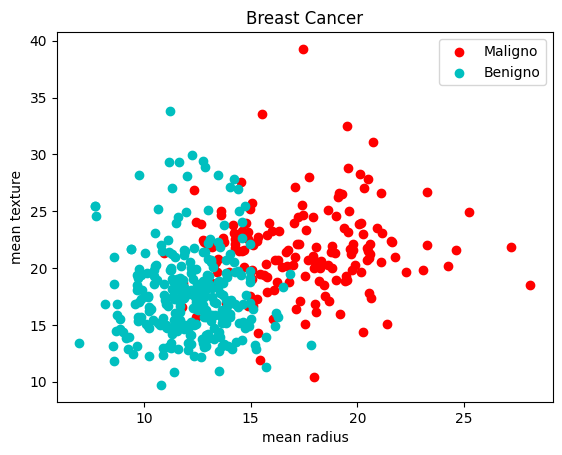

In [437]:
plt.scatter(
    x_train.loc[y_train == 0, "mean radius"],
    x_train.loc[y_train == 0, "mean texture"],
    color="r",
    label="Maligno")

plt.scatter(
    x_train.loc[y_train == 1, "mean radius"],
    x_train.loc[y_train == 1, "mean texture"],
    label="Benigno",
    color="c")

plt.xlabel("mean radius")
plt.ylabel("mean texture")
plt.title("Breast Cancer")
plt.legend()
plt.show()

**Convertir df a numpy array**

In [438]:
x_train, y_train, x_test, y_test = (
    np.array(x_train),
    np.array(y_train),
    np.array(x_test),
    np.array(y_test))

**Estandarizar variables**

In [439]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#**Regresion Logistica**

In [440]:
def logistic_regresion_fit(x, y, learning_rate, epoch):

  ones = np.ones(x.shape[0])
  x = np.column_stack((ones, x))
  beta = np.zeros(x.shape[1])

  m = len(y)

  #Gradiente Descendente
  for epoca in range(epoch):

    z = x@beta

    #funcion sigmoide
    prob_sig = 1/(1+(np.e**-z))

    epsilon = 1e-15 #0.000000000000001

    prob_sig_clip = np.clip(prob_sig, epsilon, 1 - epsilon) #limitamos los extremos
                                                     #para evitar errores de log(0)

    log_loss = -np.mean(y * np.log(prob_sig_clip) + (1 - y) * np.log(1 - prob_sig_clip))

    dLL = (x.T @ (prob_sig - y)) / m   #calcula el gradiente
    beta = beta - learning_rate * dLL  #actualiza betas

  return beta, log_loss




In [441]:
def logistic_regresion_predict(x, beta):

  ones = np.ones(x.shape[0])
  x = np.column_stack((ones, x))

  z = x @ beta

  prob_sig = 1/(1+(np.e**-z))

  y_pred = (prob_sig >= 0.5).astype(int)  #convierte la probabilidad a prediccion segun threshold

  return y_pred



**Ajustar Modelo**

In [442]:
beta, log_loss = logistic_regresion_fit(x_train, y_train, 0.01, 15000)

In [443]:
print(beta)
print(log_loss)

[ 0.84052309 -3.46151124 -0.91649964]
0.2563130034513996


**Predecir**

In [444]:
y_pred = logistic_regresion_predict(x_test, beta)

In [445]:
print(y_pred)

[0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 0 1 1 0
 1 1 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 1
 1 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1
 0 1 0]


**Matriz de Confusion**

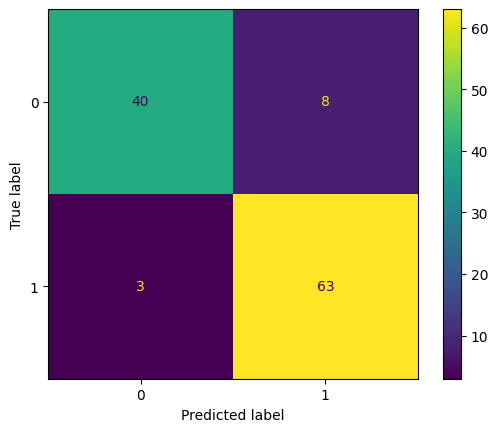

In [446]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

**Modelo ajustado con Sklearn para comparar**

In [447]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

model = LogisticRegression(penalty=None)

model.fit(x_train, y_train)

#Probabilidades
y_prob_sklearn = model.predict_proba(x_test)[:, 1]  #toma solo la columna 1 (probabilidad de pertenecer a la clase 1)

#Log-Loss
loss_sklearn = log_loss(y_test, y_prob_sklearn)

#Convertir probabilidades a etiquetas usando threshold = 0.5
y_pred_sklearn = (y_prob_sklearn >= 0.5).astype(int)

print("Pesos (Coefficients):", model.coef_)
print("Sesgo (Intercept):", model.intercept_)
print("Log-Loss:", loss_sklearn)
print("Etiquetas predichas:", y_pred_sklearn)

Pesos (Coefficients): [[-3.61611037 -0.93911016]]
Sesgo (Intercept): [0.8500798]
Log-Loss: 0.2548472573444127
Etiquetas predichas: [0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 0 1 1 0
 1 1 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 1
 1 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1
 0 1 0]


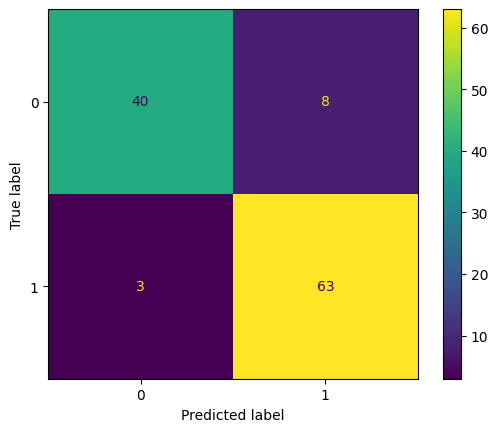

In [448]:
cm2 = confusion_matrix(y_test, y_pred_sklearn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp.plot()

plt.show()

#**Comparar**

In [458]:
beta_sklearn = np.concatenate([model.intercept_, model.coef_[0]])

nombres = ["Intercepto (b0)", "mean radius (b1)", "mean texture (b2)"]

print(f"{'Parámetro':<20}{'Tu modelo':>15}{'sklearn':>15}")
print("-" * 50)
for nombre, b_custom, b_sk in zip(nombres, beta, beta_sklearn):
    print(f"{nombre:<20}{b_custom:>15.4f}{b_sk:>15.4f}")

Parámetro                 Tu modelo        sklearn
--------------------------------------------------
Intercepto (b0)              0.8405         0.8501
mean radius (b1)            -3.4615        -3.6161
mean texture (b2)           -0.9165        -0.9391
